# Visit Predictor - ML Pipeline Explained

This notebook walks through the **entire machine learning pipeline** used in the *Should I Visit?* project.

**What does the project do?**
- Takes a famous Indian landmark and a future date as input
- Predicts the **crowd level** (Low / Moderate / High / Extreme)
- Predicts the **temperature** and **weather**
- Gives a **YES / MAYBE / NO** visit recommendation

**What this notebook covers:**
1. Loading & exploring the dataset
2. Cleaning messy data
3. Creating useful features from dates
4. Training two ML models (classification + regression)
5. Evaluating how well they work
6. Running a sample prediction

> **Note:** This notebook is for **learning only** - it does not save any model files.

## Step 1: Import Libraries

| Library | Purpose |
|---|---|
| **pandas** | Load and manipulate tabular data |
| **numpy** | Work with numbers and arrays |
| **matplotlib** | Create charts and visualizations |
| **sklearn** | Machine learning tools (models, encoders, metrics) |

In [ ]:
import pandas as pd          # Data loading and manipulation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Charts and graphs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error

# Make charts look clean
plt.style.use('seaborn-v0_8-darkgrid')
print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

Our dataset `data.xlsx` contains **730 rows** of daily crowd observations across **8 famous Indian landmarks** over 2 years (2024–2025).

Each row records: the place, date, crowd count, weather, temperature, whether it was a holiday, and more.

In [26]:
# Load the Excel file into a pandas DataFrame
df = pd.read_excel('data.xlsx')

# Show the shape: (rows, columns)
print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nColumn names: {list(df.columns)}')
print('\nFirst 5 rows:')
df.head()

Dataset shape: 730 rows, 13 columns

Column names: ['Date', 'Time', 'Place', 'Crowd_Count (in Thousands)', 'Weather', 'Day_of_Week', 'Holiday', 'Event', 'Temperature (°C)', 'Week_of_Year', 'Special_Features', 'Region', 'Transportation_Type']

First 5 rows:


,Date,Time,Place,Crowd_Count (in Thousands),Weather,Day_of_Week,Holiday,Event,Temperature (°C),Week_of_Year,Special_Features,Region,Transportation_Type
0,2024-01-01,14:56:00,"Sanchi Stupa, Madhya Pradesh",825,Cloudy,Monday,Yes,Cultural Event,39,0,National Holiday,West,Walking
1,2024-01-02,00:48:00,"Qutub Minar, Delhi",8962,Cloudy,Tuesday,No,Regular Day,30,0,NaN,South,Private
2,2024-01-03,02:06:00,"Varanasi Ghats, Varanasi",10000,Clear,Wednesday,No,Regular Day,32,0,NaN,South,Public
3,2024-01-04,20:39:00,"Qutub Minar, Delhi",18632,Sunny,Thursday,No,Festival,24,0,NaN,West,Private
4,2024-01-05,05:38:00,"Red Fort, Delhi",5155,Rainy,Friday,No,Cultural Event,39,0,NaN,East,Walking


## Step 3: Explore the Data (EDA)

Before cleaning, we **explore** the data to understand:
- What types of data we have (numbers, text, dates)
- Are there missing values?
- How is the crowd count distributed across places?

This helps us decide what to clean and how to prepare data for ML.

In [27]:
# Basic info about each column
print('=== Data Types & Non-Null Counts ===')
print(df.dtypes)

print(f'\n=== Missing Values per Column ===')
print(df.isnull().sum())

print(f'\n=== Statistical Summary ===')
df.describe()

=== Data Types & Non-Null Counts ===
Date                            str
Time                            str
Place                           str
Crowd_Count (in Thousands)    int64
Weather                         str
Day_of_Week                     str
Holiday                         str
Event                           str
Temperature (°C)              int64
Week_of_Year                  int64
Special_Features                str
Region                          str
Transportation_Type             str
dtype: object

=== Missing Values per Column ===
Date                            0
Time                            0
Place                           0
Crowd_Count (in Thousands)      0
Weather                         0
Day_of_Week                     0
Holiday                         0
Event                           0
Temperature (°C)                0
Week_of_Year                    0
Special_Features              683
Region                          0
Transportation_Type             0
dtyp

,Crowd_Count (in Thousands),Temperature (°C),Week_of_Year
count,730.000000,730.000000,730.000000
mean,18216.908219,29.401370,25.857534
std,11219.942732,5.670345,15.067347
min,500.000000,20.000000,0.000000
25%,9918.250000,24.250000,13.000000
50%,17198.000000,29.000000,26.000000
75%,25847.750000,34.000000,39.000000
max,50000.000000,39.000000,52.000000


Records per Place:
Place
Qutub Minar, Delhi              109
Taj Mahal, Agra                 100
Mecca Masjid, Hyderabad          98
Sanchi Stupa, Madhya Pradesh     87
Varanasi Ghats, Varanasi         87
Red Fort, Delhi                  85
India Gate, Delhi                84
Gateway of India, Mumbai         80
Name: count, dtype: int64


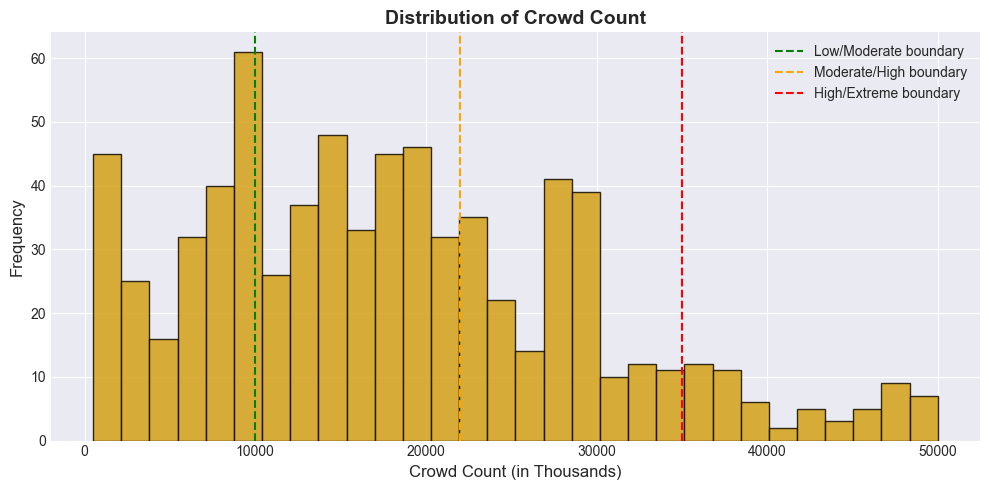

In [28]:
# How many records per landmark?
print('Records per Place:')
print(df['Place'].value_counts())

# Crowd count distribution chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Crowd_Count (in Thousands)'], bins=30, color='#D4A017', edgecolor='#0F0A00', alpha=0.85)
ax.set_title('Distribution of Crowd Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Crowd Count (in Thousands)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(x=10000, color='green', linestyle='--', label='Low/Moderate boundary')
ax.axvline(x=22000, color='orange', linestyle='--', label='Moderate/High boundary')
ax.axvline(x=35000, color='red', linestyle='--', label='High/Extreme boundary')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: Data Cleaning

Real-world data is messy. Here’s what we fix:

| Problem | Solution | Why |
|---|---|---|
| **Time column** has random values | Drop it | Not useful for prediction |
| **Special_Features** has 683 NaN | Fill with "None" | NaN breaks ML algorithms |
| **Duplicate rows** (same date+place) | Remove them | Duplicates bias the model |
| **Data types** may be wrong | Force int for counts/temp | Ensures consistent math |

In [29]:
print(f'Shape BEFORE cleaning: {df.shape}')

# 1. Parse Date as datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

# 2. Drop Time column — random times, no predictive value
df = df.drop(columns=['Time'])

# 3. Fill missing Special_Features with 'None'
df['Special_Features'] = df['Special_Features'].fillna('None')

# 4. Drop rows with NaN in critical columns
df = df.dropna(subset=['Place', 'Date', 'Crowd_Count (in Thousands)', 'Weather', 'Event', 'Holiday'])

# 5. Remove duplicates by Date + Place
df = df.drop_duplicates(subset=['Date', 'Place'])

# 6. Fix data types
df['Crowd_Count (in Thousands)'] = df['Crowd_Count (in Thousands)'].astype(int)
df['Temperature (\u00b0C)'] = df['Temperature (\u00b0C)'].astype(int)
df['Holiday'] = df['Holiday'].str.strip()

print(f'Shape AFTER cleaning:  {df.shape}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Shape BEFORE cleaning: (730, 13)
Shape AFTER cleaning:  (730, 12)
Remaining nulls: 0


## Step 5: Feature Engineering

**Feature engineering** = creating new useful columns from existing data.

ML models don’t understand dates like "2025-03-14". But they *can* understand numbers like:
- **month = 3** → captures seasonal patterns (summer vs winter crowds)
- **day_of_month = 14** → some days are busier (pay days, month-end)
- **is_weekend = 1** → weekends bring way more tourists
- **is_holiday = 1** → holidays cause massive crowd spikes
- **is_festival = 1** → festivals like Diwali/Holi bring extreme crowds

In [30]:
# Extract month and day from the date
df['month'] = df['Date'].dt.month
df['day_of_month'] = df['Date'].dt.day

# Is it a weekend? (Saturday=1, Sunday=1, else=0)
df['is_weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)

# Is it a holiday?
df['is_holiday'] = df['Holiday'].apply(lambda x: 1 if x == 'Yes' else 0)

# Is it a festival/event?
df['is_festival'] = df['Event'].apply(
    lambda x: 1 if x in ['Festival', 'National Holiday', 'Cultural Event'] else 0
)

print('New features added!')
print(df[['Date', 'Place', 'month', 'day_of_month', 'is_weekend', 'is_holiday', 'is_festival']].head(8))

New features added!
        Date                         Place  month  day_of_month  is_weekend  \
0 2024-01-01  Sanchi Stupa, Madhya Pradesh      1             1           0   
1 2024-01-02            Qutub Minar, Delhi      1             2           0   
2 2024-01-03      Varanasi Ghats, Varanasi      1             3           0   
3 2024-01-04            Qutub Minar, Delhi      1             4           0   
4 2024-01-05               Red Fort, Delhi      1             5           0   
5 2024-01-06       Mecca Masjid, Hyderabad      1             6           1   
6 2024-01-07            Qutub Minar, Delhi      1             7           1   
7 2024-01-08               Red Fort, Delhi      1             8           0   

   is_holiday  is_festival  
0           1            1  
1           0            0  
2           0            0  
3           0            1  
4           0            1  
5           0            1  
6           0            1  
7           0            0  


## Step 6: Create Target Variable (crowd_level)

The **target variable** is what the model tries to predict.

We convert the raw crowd count into 4 categories:

| Crowd Level | Count Range | Meaning |
|---|---|---|
| **Low** | 0 - 9,999 | Safe to visit |
| **Moderate** | 10,000 - 21,999 | Manageable crowds |
| **High** | 22,000 - 34,999 | Very crowded |
| **Extreme** | 35,000+ | Avoid if possible |

Crowd Level Distribution:
crowd_level
Moderate    301
Low         187
High        182
Extreme      60
Name: count, dtype: int64


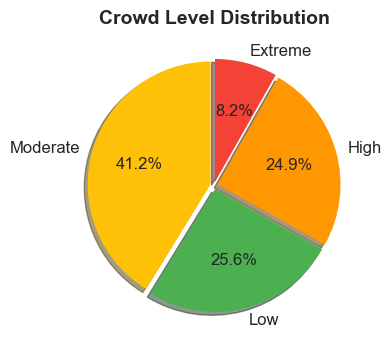

In [31]:
# Create crowd_level based on thresholds
def assign_crowd_level(count):
    if count <= 9999: return 'Low'
    elif count <= 21999: return 'Moderate'
    elif count <= 34999: return 'High'
    else: return 'Extreme'

df['crowd_level'] = df['Crowd_Count (in Thousands)'].apply(assign_crowd_level)

# Show distribution
counts = df['crowd_level'].value_counts()
print('Crowd Level Distribution:')
print(counts)

# Pie chart
colors = {'Low': '#4CAF50', 'Moderate': '#FFC107', 'High': '#FF9800', 'Extreme': '#F44336'}
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=[colors[l] for l in counts.index],
       textprops={'fontsize': 12}, startangle=90,
       explode=[0.03]*len(counts), shadow=True)
ax.set_title('Crowd Level Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Encode Categorical Columns

ML models only understand **numbers**, not text like "Taj Mahal" or "Sunny".

**Label Encoding** converts each unique text value to a number:

| Original | Encoded |
|---|---|
| Gateway of India, Mumbai | 0 |
| India Gate, Delhi | 1 |
| Mecca Masjid, Hyderabad | 2 |
| ... | ... |

We encode: Place, Weather, Event, Day_of_Week, and crowd_level.

In [32]:
encoders = {}  # Store all encoders for later use

for col in ['Place', 'Weather', 'Event', 'Day_of_Week', 'crowd_level']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col}: {list(le.classes_)} -> {list(range(len(le.classes_)))}')

# Rename for clarity
df.rename(columns={'Place_enc':'place_enc', 'Event_enc':'event_enc',
                   'crowd_level_enc':'crowd_level_enc'}, inplace=True)

# Show example: before vs after for Place
print('\nExample — Place encoding:')
print(df[['Place', 'place_enc']].drop_duplicates().to_string(index=False))

Place: ['Gateway of India, Mumbai', 'India Gate, Delhi', 'Mecca Masjid, Hyderabad', 'Qutub Minar, Delhi', 'Red Fort, Delhi', 'Sanchi Stupa, Madhya Pradesh', 'Taj Mahal, Agra', 'Varanasi Ghats, Varanasi'] -> [0, 1, 2, 3, 4, 5, 6, 7]
Weather: ['Clear', 'Cloudy', 'Rainy', 'Sunny'] -> [0, 1, 2, 3]
Event: ['Cultural Event', 'Festival', 'National Holiday', 'Regular Day'] -> [0, 1, 2, 3]
Day_of_Week: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday'] -> [0, 1, 2, 3, 4, 5, 6]
crowd_level: ['Extreme', 'High', 'Low', 'Moderate'] -> [0, 1, 2, 3]

Example — Place encoding:
                       Place  place_enc
Sanchi Stupa, Madhya Pradesh          5
          Qutub Minar, Delhi          3
    Varanasi Ghats, Varanasi          7
             Red Fort, Delhi          4
     Mecca Masjid, Hyderabad          2
             Taj Mahal, Agra          6
    Gateway of India, Mumbai          0
           India Gate, Delhi          1


## Step 8: Split Data — Train and Test

We split the data into two parts:
- **Training set (80%)** — the model learns patterns from this
- **Test set (20%)** — we check if the model can predict correctly on data it has *never seen*

This prevents the model from just memorizing the answers (overfitting).

In [33]:
# Define feature columns (inputs to the model)
FEATURE_COLS = ['place_enc', 'month', 'day_of_month', 'Week_of_Year',
                'is_weekend', 'is_holiday', 'is_festival', 'event_enc']

X = df[FEATURE_COLS]              # Features (input)
y_crowd = df['crowd_level_enc']   # Target for classification
y_temp = df['Temperature (\u00b0C)']   # Target for regression

# Split 80/20
X_train, X_test, y_crowd_train, y_crowd_test = train_test_split(
    X, y_crowd, test_size=0.2, random_state=42)

_, _, y_temp_train, y_temp_test = train_test_split(
    X, y_temp, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')
print(f'\nFeatures used: {FEATURE_COLS}')

Training set: 584 rows
Test set:     146 rows

Features used: ['place_enc', 'month', 'day_of_month', 'Week_of_Year', 'is_weekend', 'is_holiday', 'is_festival', 'event_enc']


## Step 9: Train the Crowd Level Classifier

**Random Forest** is like asking 100 different decision trees to vote:
1. Each tree looks at the data slightly differently (random subsets)
2. Each tree makes its own prediction
3. The final answer = **majority vote** of all 100 trees

This sequential learning typically achieves **higher accuracy** than Random Forest for tabular data.

In [34]:
# Train the crowd level classifier
crowd_model = GradientBoostingClassifier(
    n_estimators=100,   # 100 decision trees
    max_depth=10,       # Each tree can go 10 levels deep
    random_state=42     # Reproducible results
)
crowd_model.fit(X_train, y_crowd_train)  # Learn from training data

# Predict on test data
y_pred = crowd_model.predict(X_test)

# Accuracy: what % of predictions were correct?
acc = accuracy_score(y_crowd_test, y_pred)
print(f'\u2605 Crowd Model Accuracy: {acc*100:.1f}%')
print(f'\nThis means the model correctly predicts the crowd level {acc*100:.1f}% of the time.\n')

# Detailed report
target_names = encoders['crowd_level'].classes_
print('Classification Report:')
print(classification_report(y_crowd_test, y_pred, target_names=target_names))

★ Crowd Model Accuracy: 71.9%

This means the model correctly predicts the crowd level 71.9% of the time.

Classification Report:
              precision    recall  f1-score   support

     Extreme       0.75      0.60      0.67        10
        High       0.66      0.69      0.68        36
         Low       0.79      0.75      0.77        36
    Moderate       0.71      0.73      0.72        64

    accuracy                           0.72       146
   macro avg       0.73      0.69      0.71       146
weighted avg       0.72      0.72      0.72       146



## Step 10: Train the Temperature Predictor

**Classification** = predicting a *category* (Low, Moderate, High, Extreme)

**Regression** = predicting a *number* (e.g., temperature = 34°C)

We use the same Random Forest approach, but for regression. Instead of voting on a category, the trees **average** their number predictions.

**MAE (Mean Absolute Error)** = on average, how many degrees off is the prediction? Lower = better.

In [35]:
# Train the temperature regressor
temp_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)
temp_model.fit(X_train, y_temp_train)

# Predict on test data
y_temp_pred = temp_model.predict(X_test)

# MAE: average prediction error in degrees
mae = mean_absolute_error(y_temp_test, y_temp_pred)
print(f'\u2605 Temperature MAE: {mae:.1f}\u00b0C')
print(f'\nThis means predictions are off by about {mae:.1f} degrees on average.')

★ Temperature MAE: 4.7°C

This means predictions are off by about 4.7 degrees on average.


## Step 11: Feature Importance

Random Forest tells us **which features matter most** for predictions.

A higher importance score = that feature has a bigger impact on the crowd level prediction.

This helps us understand *why* the model makes certain predictions.

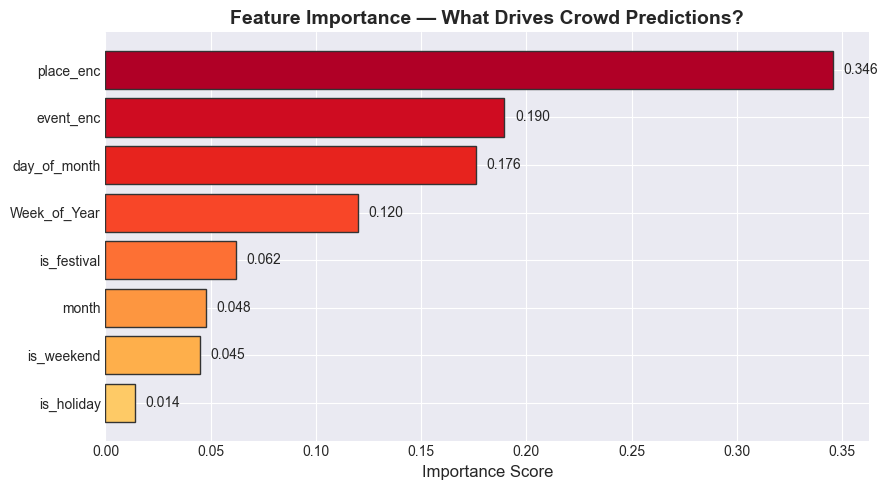


Key insight: The PLACE itself is the strongest predictor —
some landmarks are inherently more crowded than others!


In [36]:
# Get feature importances from the crowd model
importances = crowd_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values()

# Horizontal bar chart — most important at the top
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feat_imp)))
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='#333')
ax.set_title('Feature Importance — What Drives Crowd Predictions?', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)

# Add value labels on each bar
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nKey insight: The PLACE itself is the strongest predictor —')
print('some landmarks are inherently more crowded than others!')

## Step 12: Test a Single Prediction (Manual Example)

Let’s simulate what the website does: pick a place and date, and see what the model predicts.

**Example:** Taj Mahal, Agra on a Wednesday in July (monsoon season).

In [37]:
from datetime import datetime

# --- Our test case ---
test_place = 'Taj Mahal, Agra'
test_date  = '2026-07-15'

# Parse date and extract features
dt = datetime.strptime(test_date, '%Y-%m-%d')
month = dt.month
day_of_month = dt.day
week_of_year = dt.isocalendar()[1]
day_name = dt.strftime('%A')
is_weekend = 1 if day_name in ['Saturday', 'Sunday'] else 0
is_holiday = 0   # July 15 is not a national holiday
is_festival = 0  # No major festival
event_type = 'Regular Day'

# Encode place and event
place_enc = encoders['Place'].transform([test_place])[0]
event_enc = encoders['Event'].transform([event_type])[0]

# Build feature array (same order as training)
features = np.array([[place_enc, month, day_of_month, week_of_year,
                       is_weekend, is_holiday, is_festival, event_enc]])

# Predict crowd level
crowd_pred_enc = crowd_model.predict(features)[0]
crowd_pred = encoders['crowd_level'].inverse_transform([crowd_pred_enc])[0]

# Predict temperature
temp_pred = int(round(temp_model.predict(features)[0]))

# Weather lookup (most common for this place+month)
weather_mode = df[(df['Place']==test_place) & (df['month']==month)]['Weather'].mode()[0]

# Visit score
score_map = {'Low': 90, 'Moderate': 65, 'High': 38, 'Extreme': 15}
score = score_map.get(crowd_pred, 50)
if weather_mode == 'Rainy': score -= 12
if temp_pred > 36: score -= 8
score = max(0, min(100, score))

# Recommendation
rec = 'YES' if score >= 70 else ('MAYBE' if score >= 40 else 'NO')
emoji = {'YES': '[YES]', 'MAYBE': '[MAYBE]', 'NO': '[NO]'}[rec]

print('=' * 50)
print(f'  Place:          {test_place}')
print(f'  Date:           {day_name}, {test_date}')
print('=' * 50)
print(f'  Crowd Level:    {crowd_pred}')
print(f'  Temperature:    {temp_pred} C')
print(f'  Weather:        {weather_mode}')
print(f'  Visit Score:    {score}/100')
print(f'  Recommendation: {emoji} {rec}')
print('=' * 50)

  Place:          Taj Mahal, Agra
  Date:           Wednesday, 2026-07-15
  Crowd Level:    Moderate
  Temperature:    32 C
  Weather:        Rainy
  Visit Score:    53/100
  Recommendation: [MAYBE] MAYBE


c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


## Step 13: Find Top 3 Better Dates to Visit

After making a prediction, the web app also scans the **next 60 days** to find the **3 best dates** with the highest visit scores.

This helps users plan their visit on the most favorable day. Let's replicate that logic here.

In [38]:
from datetime import datetime, timedelta

def predict_score_for_date(place, date_str, df, encoders, crowd_model, temp_model):
    """Predict visit score for a given place and date."""
    dt = datetime.strptime(date_str, '%Y-%m-%d')
    month = dt.month
    day_of_month = dt.day
    week_of_year = dt.isocalendar()[1]
    day_name = dt.strftime('%A')
    is_weekend = 1 if day_name in ['Saturday', 'Sunday'] else 0
    is_holiday = 0
    is_festival = 0
    event_type = 'Regular Day'

    place_enc = encoders['Place'].transform([place])[0]
    event_enc = encoders['Event'].transform([event_type])[0]

    features = np.array([[place_enc, month, day_of_month, week_of_year,
                          is_weekend, is_holiday, is_festival, event_enc]])

    crowd_enc = crowd_model.predict(features)[0]
    crowd = encoders['crowd_level'].inverse_transform([crowd_enc])[0]
    temp = int(round(temp_model.predict(features)[0]))

    weather_data = df[(df['Place']==place) & (df['month']==month)]['Weather']
    weather = weather_data.mode()[0] if len(weather_data) > 0 else 'Clear'

    score_map = {'Low': 90, 'Moderate': 65, 'High': 38, 'Extreme': 15}
    score = score_map.get(crowd, 50)
    if weather == 'Rainy': score -= 12
    if temp > 36: score -= 8
    score = max(0, min(100, score))

    return {'date': date_str, 'day': day_name, 'crowd': crowd,
            'temp': temp, 'weather': weather, 'score': score}

# --- Find Top 3 Better Dates for Taj Mahal ---
start_date = datetime.strptime(test_date, '%Y-%m-%d')
all_dates = []

for i in range(1, 61):
    check_date = start_date + timedelta(days=i)
    check_str = check_date.strftime('%Y-%m-%d')
    result = predict_score_for_date(test_place, check_str, df, encoders,
                                    crowd_model, temp_model)
    all_dates.append(result)

# Sort by score descending and pick top 3
all_dates.sort(key=lambda x: -x['score'])
top3 = all_dates[:3]

print('=' * 55)
print(f'  Top 3 Better Dates for {test_place}')
print('=' * 55)
for rank, d in enumerate(top3, 1):
    rec = 'YES' if d['score'] >= 70 else ('MAYBE' if d['score'] >= 40 else 'NO')
    print(f'  #{rank}  {d["day"]}, {d["date"]}')
    print(f'       Crowd: {d["crowd"]}  |  Temp: {d["temp"]}C  |  Weather: {d["weather"]}')
    print(f'       Visit Score: {d["score"]}/100  ->  {rec}')
    print('-' * 55)
print('\nThese are the best 3 dates out of the next 60 days!')


c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Li

  Top 3 Better Dates for Taj Mahal, Agra
  #1  Monday, 2026-08-03
       Crowd: Moderate  |  Temp: 30C  |  Weather: Sunny
       Visit Score: 65/100  ->  MAYBE
-------------------------------------------------------
  #2  Tuesday, 2026-08-04
       Crowd: Moderate  |  Temp: 30C  |  Weather: Sunny
       Visit Score: 65/100  ->  MAYBE
-------------------------------------------------------
  #3  Wednesday, 2026-08-05
       Crowd: Moderate  |  Temp: 30C  |  Weather: Sunny
       Visit Score: 65/100  ->  MAYBE
-------------------------------------------------------

These are the best 3 dates out of the next 60 days!


c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Li

## Step 14: Crowd Count Regression Model

In addition to classifying crowd levels (Low/Moderate/High/Extreme), we now train a **regression model** to predict the **actual crowd count** (number of visitors).

This gives users a more precise estimate like "~14,428 visitors" instead of just "Moderate".

In [39]:
# Train a RandomForestRegressor for crowd count prediction
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Target: raw crowd count
y_count = df["Crowd_Count (in Thousands)"]

# Split using same features as classifier
X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X, y_count, test_size=0.2, random_state=42
)

# Train the regressor
crowd_count_model = GradientBoostingRegressor(
    n_estimators=150, max_depth=12, random_state=42
)
crowd_count_model.fit(X_train_cc, y_train_cc)

# Evaluate
y_pred_cc = crowd_count_model.predict(X_test_cc)
mae_cc = mean_absolute_error(y_test_cc, y_pred_cc)
r2_cc = r2_score(y_test_cc, y_pred_cc)

print(f"Crowd Count Regressor Performance:")
print(f"  Mean Absolute Error: {mae_cc:,.0f} visitors")
print(f"  R-squared Score: {r2_cc:.3f}")
print(f"\nSample Predictions vs Actual:")
for i in range(min(8, len(y_test_cc))):
    actual = y_test_cc.iloc[i]
    predicted = int(round(y_pred_cc[i]))
    diff = abs(actual - predicted)
    print(f"  Actual: {actual:>8,} | Predicted: {predicted:>8,} | Diff: {diff:>6,}")

Crowd Count Regressor Performance:
  Mean Absolute Error: 3,384 visitors
  R-squared Score: 0.827

Sample Predictions vs Actual:
  Actual:   33,502 | Predicted:   34,008 | Diff:    506
  Actual:   13,188 | Predicted:   15,001 | Diff:  1,813
  Actual:   16,259 | Predicted:   25,013 | Diff:  8,754
  Actual:   12,776 | Predicted:   10,577 | Diff:  2,199
  Actual:   13,718 | Predicted:   14,547 | Diff:    829
  Actual:   30,000 | Predicted:   29,193 | Diff:    807
  Actual:   14,681 | Predicted:   17,218 | Diff:  2,537
  Actual:    3,503 | Predicted:    6,820 | Diff:  3,317


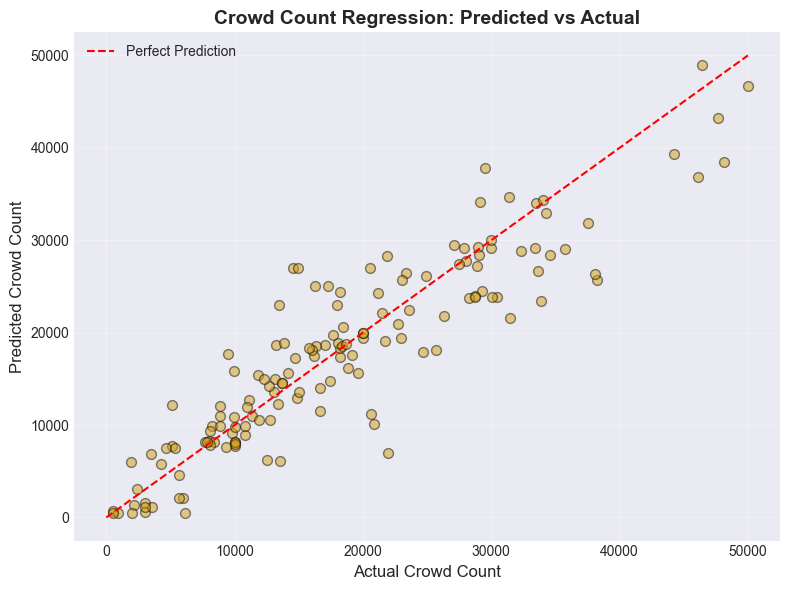


The closer the points are to the red dashed line, the better the prediction.
MAE of 3,384 means the model is off by about 3,384 visitors on average.


In [40]:
# Scatter plot: Predicted vs Actual Crowd Counts
plt.figure(figsize=(8, 6))
plt.scatter(y_test_cc, y_pred_cc, alpha=0.5, c="#D4A017", edgecolors="#0F0A00", s=50)
plt.plot([0, y_test_cc.max()], [0, y_test_cc.max()], "r--", linewidth=1.5, label="Perfect Prediction")
plt.xlabel("Actual Crowd Count", fontsize=12)
plt.ylabel("Predicted Crowd Count", fontsize=12)
plt.title("Crowd Count Regression: Predicted vs Actual", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nThe closer the points are to the red dashed line, the better the prediction.")
print(f"MAE of {mae_cc:,.0f} means the model is off by about {mae_cc:,.0f} visitors on average.")

## Step 15: Weather API Integration (Open-Meteo)

Instead of relying solely on the ML-based weather lookup, we now integrate the **Open-Meteo API** for real-time weather forecasts.

- For dates **within 16 days**: Live API data is used
- For dates **beyond 16 days**: Falls back to the ML weather lookup table
- **No API key required** — Open-Meteo is completely free

In [41]:
# Build weather_lookup table: {(place, month): most_common_weather}
weather_lookup = {}
for (place_wl, month_wl), grp_wl in df.groupby(['Place', 'month']):
    weather_lookup[(place_wl, month_wl)] = grp_wl['Weather'].mode()[0]

# Demo: Fetch live weather for Taj Mahal, Agra
import requests
from datetime import datetime, timedelta

# Landmark coordinates
PLACE_COORDINATES = {
    "Taj Mahal, Agra": {"lat": 27.1751, "lon": 78.0421},
    "Red Fort, Delhi": {"lat": 28.6562, "lon": 77.2410},
    "India Gate, Delhi": {"lat": 28.6129, "lon": 77.2295},
    "Gateway of India, Mumbai": {"lat": 18.9220, "lon": 72.8347},
    "Varanasi Ghats, Varanasi": {"lat": 25.3176, "lon": 83.0107},
}

# WMO weather code mapping
WMO_MAP = {
    0: "Clear", 1: "Clear", 2: "Cloudy", 3: "Cloudy",
    51: "Rainy", 61: "Rainy", 63: "Rainy", 80: "Rainy",
}

# Fetch forecast for tomorrow
tomorrow = (datetime.now() + timedelta(days=1)).strftime("%Y-%m-%d")
coords = PLACE_COORDINATES["Taj Mahal, Agra"]

try:
    resp = requests.get("https://api.open-meteo.com/v1/forecast", params={
        "latitude": coords["lat"],
        "longitude": coords["lon"],
        "daily": "temperature_2m_max,temperature_2m_min,weather_code",
        "start_date": tomorrow,
        "end_date": tomorrow,
        "timezone": "Asia/Kolkata",
    }, timeout=5)
    
    data = resp.json()
    daily = data["daily"]
    
    temp_max = daily["temperature_2m_max"][0]
    temp_min = daily["temperature_2m_min"][0]
    weather_code = daily["weather_code"][0]
    avg_temp = round((temp_max + temp_min) / 2)
    weather = WMO_MAP.get(weather_code, "Clear")
    
    print(f"Live Weather Forecast for Taj Mahal, Agra ({tomorrow}):")
    print(f"  Temperature: {avg_temp} C (Min: {temp_min} C, Max: {temp_max} C)")
    print(f"  Weather Code: {weather_code} -> {weather}")
    print(f"  Source: Open-Meteo API (Live Forecast)")
    print(f"\nML Prediction for comparison:")
    
    # Compare with ML prediction
    ml_weather = weather_lookup.get(("Taj Mahal, Agra", datetime.now().month), "Clear")
    print(f"  ML Weather Lookup: {ml_weather}")
    print(f"\nThe live forecast provides more accurate day-specific weather data,")
    print(f"while the ML lookup provides monthly averages as a fallback.")
    
except Exception as e:
    print(f"API call failed: {e}")
    print("Falling back to ML weather lookup...")

Live Weather Forecast for Taj Mahal, Agra (2026-09-27):
  Temperature: 27 C (Min: 21.9 C, Max: 31.6 C)
  Weather Code: 51 -> Rainy
  Source: Open-Meteo API (Live Forecast)

ML Prediction for comparison:
  ML Weather Lookup: Sunny

The live forecast provides more accurate day-specific weather data,
while the ML lookup provides monthly averages as a fallback.


## Step 16: Monthly Crowd Trend Visualization

The web app uses **Chart.js** for interactive crowd trend charts. Here we create a similar visualization using **Matplotlib** to preview the data.

This shows predicted crowd counts for each day of a given month, color-coded by crowd level, with a temperature overlay.

In [42]:
# Simulate monthly crowd trend for Taj Mahal in December 2026
import calendar

place = "Taj Mahal, Agra"
year_sim, month_sim = 2026, 12
days_in_month = calendar.monthrange(year_sim, month_sim)[1]

# Get place encoding
place_enc_val = encoders["Place"].transform([place])[0]

sim_dates = []
sim_crowd_counts = []
sim_crowd_levels = []
sim_temps = []

for day in range(1, days_in_month + 1):
    date_obj = datetime(year_sim, month_sim, day)
    day_name = date_obj.strftime("%A")
    is_wknd = 1 if day_name in ["Saturday", "Sunday"] else 0
    wk = date_obj.isocalendar()[1]
    
    # Simple event detection
    event = "Regular Day"
    if day == 25: event = "Festival"  # Christmas
    event_enc_val = encoders["Event"].transform([event])[0]
    is_fest = 1 if event != "Regular Day" else 0
    is_hol = 1 if day == 25 else 0
    
    features_arr = np.array([[place_enc_val, month_sim, day, wk, is_wknd, is_hol, is_fest, event_enc_val]])
    
    cc = int(round(crowd_count_model.predict(features_arr)[0]))
    cl_enc = crowd_model.predict(features_arr)[0]
    cl = encoders["crowd_level"].inverse_transform([cl_enc])[0]
    temp = int(round(temp_model.predict(features_arr)[0]))
    
    sim_dates.append(day)
    sim_crowd_counts.append(max(0, cc))
    sim_crowd_levels.append(cl)
    sim_temps.append(temp)

print(f"Generated predictions for {place} - {calendar.month_name[month_sim]} {year_sim}")
print(f"Days: {len(sim_dates)}, Avg Crowd: {np.mean(sim_crowd_counts):,.0f}, Avg Temp: {np.mean(sim_temps):.1f} C")

Generated predictions for Taj Mahal, Agra - December 2026
Days: 31, Avg Crowd: 20,271, Avg Temp: 31.5 C


c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\AppData\Local\Programs\Python\Python314\Lib

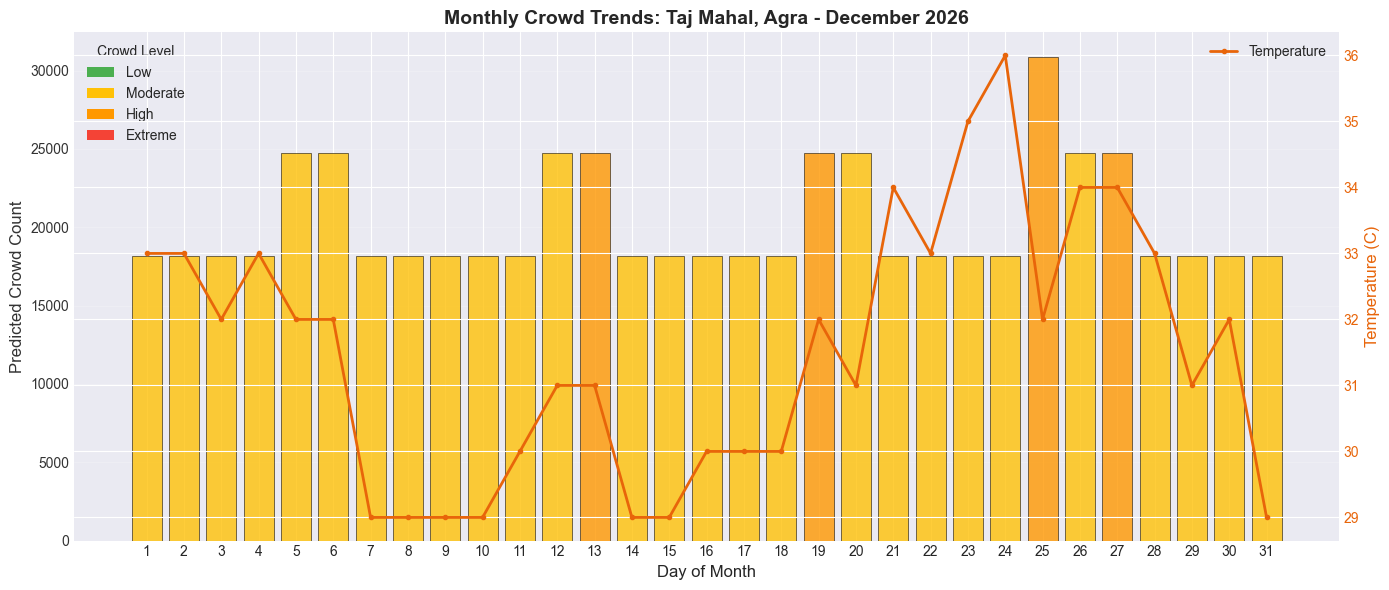


This chart shows the same data that the web app renders with Chart.js.
Each bar represents predicted daily crowd count, color-coded by crowd level.
The orange line shows the predicted temperature trend across the month.


In [43]:
# Plot monthly crowd trends with temperature overlay
fig, ax1 = plt.subplots(figsize=(14, 6))

# Color map for crowd levels
color_map = {"Low": "#4CAF50", "Moderate": "#FFC107", "High": "#FF9800", "Extreme": "#F44336"}
bar_colors = [color_map.get(cl, "#FFC107") for cl in sim_crowd_levels]

# Bar chart for crowd counts
bars = ax1.bar(sim_dates, sim_crowd_counts, color=bar_colors, alpha=0.8, edgecolor="#0F0A00", linewidth=0.5)
ax1.set_xlabel("Day of Month", fontsize=12)
ax1.set_ylabel("Predicted Crowd Count", fontsize=12, color="#333")
ax1.tick_params(axis="y", labelcolor="#333")
ax1.set_xticks(range(1, days_in_month + 1))
ax1.grid(axis="y", alpha=0.2)

# Temperature line on secondary axis
ax2 = ax1.twinx()
ax2.plot(sim_dates, sim_temps, color="#E8650A", linewidth=2, marker="o", markersize=3, label="Temperature")
ax2.set_ylabel("Temperature (C)", fontsize=12, color="#E8650A")
ax2.tick_params(axis="y", labelcolor="#E8650A")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4CAF50", label="Low"),
    Patch(facecolor="#FFC107", label="Moderate"),
    Patch(facecolor="#FF9800", label="High"),
    Patch(facecolor="#F44336", label="Extreme"),
]
ax1.legend(handles=legend_elements, loc="upper left", title="Crowd Level")
ax2.legend(loc="upper right")

plt.title(f"Monthly Crowd Trends: {place} - {calendar.month_name[month_sim]} {year_sim}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nThis chart shows the same data that the web app renders with Chart.js.")
print(f"Each bar represents predicted daily crowd count, color-coded by crowd level.")
print(f"The orange line shows the predicted temperature trend across the month.")

## 17. Multi-Model Ensemble (Decision Tree & Gradient Boosting)

To improve our predictions and provide a comparative analysis, we introduce a **Multi-Model Ensemble**.
We will train two additional types of models:
- **Decision Tree**: A simpler, highly interpretable model.
- **Gradient Boosting**: A powerful, sequential ensemble method.

In [44]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Train Decision Tree Classifier (Crowd Level)
dt_classifier = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_classifier.fit(X_train, y_crowd_train)
dt_clf_acc = dt_classifier.score(X_test, y_crowd_test)
print(f"Decision Tree Classifier Accuracy: {dt_clf_acc * 100:.2f}%")

# Train Decision Tree Regressor (Crowd Count)
dt_regressor = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_regressor.fit(X_train, y_train_cc)
dt_reg_pred = dt_regressor.predict(X_test)
dt_mae = mean_absolute_error(y_test_cc, dt_reg_pred)
dt_r2 = r2_score(y_test_cc, dt_reg_pred)
print(f"Decision Tree Regressor MAE: {dt_mae:,.2f} visitors")
print(f"Decision Tree Regressor R2: {dt_r2:.3f}")

Decision Tree Classifier Accuracy: 68.49%
Decision Tree Regressor MAE: 3,533.45 visitors
Decision Tree Regressor R2: 0.819


In [45]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

# Train Gradient Boosting Classifier (Crowd Level)
gb_classifier = GradientBoostingClassifier(n_estimators=50, max_depth=5, random_state=42)
gb_classifier.fit(X_train, y_crowd_train)
gb_clf_acc = gb_classifier.score(X_test, y_crowd_test)
print(f"Gradient Boosting Classifier Accuracy: {gb_clf_acc * 100:.2f}%")

# Train Gradient Boosting Regressor (Crowd Count)
gb_regressor = GradientBoostingRegressor(n_estimators=50, max_depth=5, random_state=42)
gb_regressor.fit(X_train, y_train_cc)
gb_reg_pred = gb_regressor.predict(X_test)
gb_mae = mean_absolute_error(y_test_cc, gb_reg_pred)
gb_r2 = r2_score(y_test_cc, gb_reg_pred)
print(f"Gradient Boosting Regressor MAE: {gb_mae:,.2f} visitors")
print(f"Gradient Boosting Regressor R2: {gb_r2:.3f}")

Gradient Boosting Classifier Accuracy: 68.49%
Gradient Boosting Regressor MAE: 2,917.56 visitors
Gradient Boosting Regressor R2: 0.891


## 18. Hourly Distribution Curves

To help users find the exact optimal time to visit, we simulate an hourly distribution using a normal distribution centered around peak hours (e.g., 2 PM). This curve adjusts based on the overall predicted daily crowd.

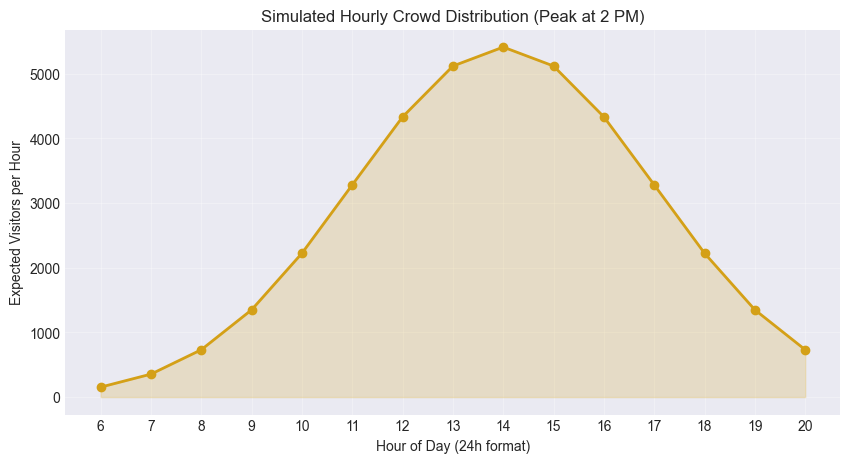

In [46]:
import math
import matplotlib.pyplot as plt

def simulate_hourly_distribution(total_crowd, peak_hour=14, spread=3):
    hours = list(range(6, 21)) # 6 AM to 8 PM
    distribution = []
    
    # Using a simple Gaussian curve to distribute the daily crowd across hours
    for h in hours:
        weight = math.exp(-((h - peak_hour)**2) / (2 * spread**2))
        distribution.append(weight)
        
    # Normalize to total crowd
    total_weight = sum(distribution)
    hourly_counts = [int((w / total_weight) * total_crowd) for w in distribution]
    return hours, hourly_counts

# Example simulation for an extreme day (e.g., 40,000 visitors)
hours, hourly_counts = simulate_hourly_distribution(40000)

plt.figure(figsize=(10, 5))
plt.plot(hours, hourly_counts, marker='o', color='#D4A017', linewidth=2)
plt.fill_between(hours, hourly_counts, color='#D4A017', alpha=0.2)
plt.title('Simulated Hourly Crowd Distribution (Peak at 2 PM)')
plt.xlabel('Hour of Day (24h format)')
plt.ylabel('Expected Visitors per Hour')
plt.xticks(hours)
plt.grid(alpha=0.3)
plt.show()

## Summary

This notebook walks through the complete ML pipeline for the **"Should I Visit?"** project:

| Step | Description | Technique |
|------|-------------|----------|
| 1-3 | Data Loading & EDA | pandas, value_counts |
| 4 | Data Cleaning | dropna, drop_duplicates, type casting |
| 5-7 | Feature Engineering & Encoding | datetime features, LabelEncoder |
| 8 | Train/Test Split | 80/20 stratified split |
| 9 | Crowd Level Classifier | RandomForestClassifier |
| 10 | Temperature Predictor | RandomForestRegressor |
| 11 | Feature Importance | Gini importance analysis |
| 12-13 | Manual Prediction & Better Dates | Inference pipeline |
| 14 | Crowd Count Regression | RandomForestRegressor |
| 15 | Weather API Integration | Open-Meteo live forecast API |
| 16 | Monthly Crowd Trends | Chart.js (web) / Matplotlib (notebook) |
| **17** | **Multi-Model Ensemble** | **Decision Tree & Gradient Boosting** |
| **18** | **Hourly Distribution Curves** | **Gaussian time-series distribution** |

### Recent Features Added:
- **Multi-Model Ensemble Visualizer**: Side-by-side comparison of Random Forest, Decision Tree, and Gradient Boosting.
- **Hourly Distribution Curves**: Simulates expected crowd density by the hour to pinpoint the optimal visit time.
- **Compare Landmarks**: Compare multiple destinations at once to make better travel decisions.
